<a href="https://colab.research.google.com/github/Nileshkadam2002/Data_Science/blob/main/Fake_Jobs_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
josereimondez_fake_jobs_posting_detection_path = kagglehub.dataset_download('josereimondez/fake-jobs-posting-detection')

print('Data source import complete.')


100%|██████████| 16.1M/16.1M [00:00<00:00, 90.0MB/s]

Extracting files...


Data source import complete.


In [3]:
import kagglehub
path = kagglehub.dataset_download("josereimondez/fake-jobs-posting-detection")

100%|██████████| 16.1M/16.1M [00:00<00:00, 105MB/s]

Extracting files...


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [10]:
pd.options.display.max_rows = 10
df = pd.read_csv('/content/fake_job_postings[1].csv', engine='python', on_bad_lines='skip')
df

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17070,17071,Developer - Mobile iOS,"US, PA, Harrisburg",NaN,NaN,NaN,Position: Developer - Mobile iOSLocation: Harr...,SkillRequired / DesiredAmount of ExperienceExp...,NaN,0,0,0,Contract,Mid-Senior level,NaN,Government Administration,Information Technology,0
17071,17072,Title Closer / Title Agent,"US, NC, Raleigh",NaN,NaN,Network Closing Services has been serving Lend...,Looking for a change? Not happy where you are...,Are you a top Closer in your market? Are you a...,"We provide a fun and rewarding atmosphere, our...",0,1,1,Full-time,Mid-Senior level,NaN,Real Estate,NaN,0
17072,17073,Sr. Architect,"US, PA, Harrisburg",NaN,NaN,NaN,Position Title: Sr. ArchitectLocation: Harrisb...,Position Description:Direct the architectural ...,NaN,0,0,0,Contract,Mid-Senior level,Unspecified,Government Relations,Information Technology,0
17073,17074,Title Closer,"US, GA, Atlanta",NaN,NaN,Network Closing Services has been serving Lend...,Not happy where you are? Looking for a change...,Are you a top Closer in your market? Are you a...,"We provide a fun and rewarding atmosphere, our...",0,1,1,Full-time,Mid-Senior level,High School or equivalent,Real Estate,NaN,0


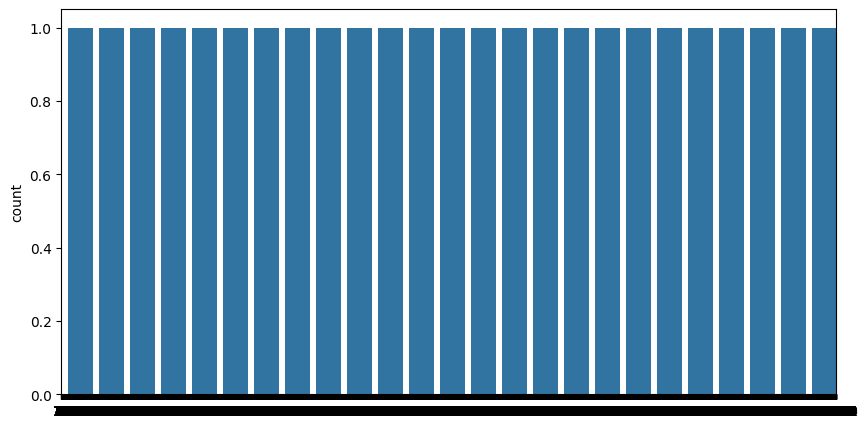

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(df['fraudulent']);

In [12]:
(df[df['fraudulent'] == 0].shape[0])/df.shape[0]

0.9684919472913617

# UNBALANCE DATA

# Data Preprocessing

In [13]:
def Information (df) :
    df.replace('?' , np.nan , inplace = True )
    nulls = (df.shape[0] - df.dropna(axis = 0).shape[0])
    nulls_per = (df.shape[0] - df.dropna(axis = 0).shape[0]) / df.shape[0]
    dup , dup_per = df.duplicated().sum() , (df.duplicated().sum()) / df.shape[0]
    numerical_columns = list((df.select_dtypes(include=np.number)).columns)
    categorical_columns = list(df.select_dtypes(include = ['object']).columns)
    numerical_col_dict = {}
    for col in numerical_columns :
        if df[col].nunique() > 10 :
            numerical_col_dict[col] = 'Continuous'

        else :
            numerical_col_dict[col] = 'Discrete'
    categorical_col_dict = {}
    for col in categorical_columns :
        if df[col].nunique() > 10 :
            categorical_col_dict[col] = 'Continuous'

        else :
            categorical_col_dict[col] = 'Classes'
    x = []
    for col in df.columns :
        x.append([col , df[col].unique() ,df[col].nunique(),df[col].dtype,df[col].isna().sum(),int((df[col].isna().sum())/df.shape[0] * 100)  ])

    x = pd.DataFrame(x ,columns=['Feature','Unique_Values','No.OfUniqueValues','DataType','NoOfNulls','Nulls %'])

    print('\n','There is : {}  Nulls, Representing {} % of The Data'.format(nulls , '%.2f'%nulls_per ))
    print('\n','There is : {}  Duplicated, Representing {} % of The Data'.format(dup , '%.2f'%dup_per))
    print('\n','Numerical Columns : {}'.format(numerical_col_dict))
    print('\n','Categorical Columns : {}'.format(categorical_col_dict))

    return x

In [14]:
pd.options.display.max_rows = None
Information(df)


 There is : 16323  Nulls, Representing 0.96 % of The Data

 There is : 0  Duplicated, Representing 0.00 % of The Data

 Numerical Columns : {'job_id': 'Continuous', 'telecommuting': 'Discrete', 'has_company_logo': 'Discrete', 'has_questions': 'Discrete', 'fraudulent': 'Discrete'}

 Categorical Columns : {'title': 'Continuous', 'location': 'Continuous', 'department': 'Continuous', 'salary_range': 'Continuous', 'company_profile': 'Continuous', 'description': 'Continuous', 'requirements': 'Continuous', 'benefits': 'Continuous', 'employment_type': 'Classes', 'required_experience': 'Classes', 'required_education': 'Continuous', 'industry': 'Continuous', 'function': 'Continuous'}


,Feature,Unique_Values,No.OfUniqueValues,DataType,NoOfNulls,Nulls %
0,job_id,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",17075,int64,0,0
1,title,"[Marketing Intern, Customer Service - Cloud Vi...",10800,object,0,0
2,location,"[US, NY, New York, NZ, , Auckland, US, IA, Wev...",2986,object,330,1
3,department,"[Marketing, Success, nan, Sales, ANDROIDPIT, H...",1300,object,11010,64
4,salary_range,"[nan, 20000-28000, 100000-120000, 120000-15000...",845,object,14356,84
5,company_profile,"[We're Food52, and we've created a groundbreak...",1681,object,2942,17
6,description,"[Food52, a fast-growing, James Beard Award-win...",14189,object,0,0
7,requirements,[Experience with content management systems a ...,11516,object,2544,14
8,benefits,"[nan, What you will get from usThrough being p...",5965,object,6898,40
9,telecommuting,"[0, 1]",2,int64,0,0


In [15]:
df.drop('job_id' , axis = 1 ,inplace = True)

In [16]:
pd.options.display.max_rows = 10
df

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17070,Developer - Mobile iOS,"US, PA, Harrisburg",NaN,NaN,NaN,Position: Developer - Mobile iOSLocation: Harr...,SkillRequired / DesiredAmount of ExperienceExp...,NaN,0,0,0,Contract,Mid-Senior level,NaN,Government Administration,Information Technology,0
17071,Title Closer / Title Agent,"US, NC, Raleigh",NaN,NaN,Network Closing Services has been serving Lend...,Looking for a change? Not happy where you are...,Are you a top Closer in your market? Are you a...,"We provide a fun and rewarding atmosphere, our...",0,1,1,Full-time,Mid-Senior level,NaN,Real Estate,NaN,0
17072,Sr. Architect,"US, PA, Harrisburg",NaN,NaN,NaN,Position Title: Sr. ArchitectLocation: Harrisb...,Position Description:Direct the architectural ...,NaN,0,0,0,Contract,Mid-Senior level,Unspecified,Government Relations,Information Technology,0
17073,Title Closer,"US, GA, Atlanta",NaN,NaN,Network Closing Services has been serving Lend...,Not happy where you are? Looking for a change...,Are you a top Closer in your market? Are you a...,"We provide a fun and rewarding atmosphere, our...",0,1,1,Full-time,Mid-Senior level,High School or equivalent,Real Estate,NaN,0


In [17]:
df.reset_index(drop=True ,inplace=True)

# Impute Nulls

In [18]:
df['location'] = df['location'].fillna(value = df['location'].value_counts().index[0] )

In [19]:
for idx in (df[df['department'].isna()]['title'].index) :
    if 'Marketing' in df.at[idx ,'title' ] :
        df.at[idx , 'department'] = 'Marketing'
    elif 'Sales' in df.at[idx ,'title' ] :
        df.at[idx , 'department'] = 'Sales'
    elif ('Accountant' in df.at[idx ,'title' ])|('Accounting' in df.at[idx ,'title' ] ) :
        df.at[idx , 'department'] = 'Accounting'
    elif ('Engineer' in df.at[idx ,'title' ] )|('Engineering' in df.at[idx ,'title' ] ) :
        df.at[idx , 'department'] = 'Engineering'
    else :
        df.at[idx , 'department'] = df.at[idx , 'title']


In [20]:
for idx in (df['salary_range'].dropna()).index :
    Range = df.at[idx , 'salary_range'].split('-')
    try :
        start = int(Range[0])
        if start < 1000 :
            df.at[idx ,'salary_range' ] = 0
        else :
            df.at[idx ,'salary_range' ] = start

    except ValueError :
        df.at[idx ,'salary_range' ] = 0

df['salary_range'] = df['salary_range'].fillna(0)

In [21]:
df

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,0,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,0,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Commissioning Machinery Assistant (CMA),0,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,0,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",Bill Review Manager,0,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17070,Developer - Mobile iOS,"US, PA, Harrisburg",Developer - Mobile iOS,0,NaN,Position: Developer - Mobile iOSLocation: Harr...,SkillRequired / DesiredAmount of ExperienceExp...,NaN,0,0,0,Contract,Mid-Senior level,NaN,Government Administration,Information Technology,0
17071,Title Closer / Title Agent,"US, NC, Raleigh",Title Closer / Title Agent,0,Network Closing Services has been serving Lend...,Looking for a change? Not happy where you are...,Are you a top Closer in your market? Are you a...,"We provide a fun and rewarding atmosphere, our...",0,1,1,Full-time,Mid-Senior level,NaN,Real Estate,NaN,0
17072,Sr. Architect,"US, PA, Harrisburg",Sr. Architect,0,NaN,Position Title: Sr. ArchitectLocation: Harrisb...,Position Description:Direct the architectural ...,NaN,0,0,0,Contract,Mid-Senior level,Unspecified,Government Relations,Information Technology,0
17073,Title Closer,"US, GA, Atlanta",Title Closer,0,Network Closing Services has been serving Lend...,Not happy where you are? Looking for a change...,Are you a top Closer in your market? Are you a...,"We provide a fun and rewarding atmosphere, our...",0,1,1,Full-time,Mid-Senior level,High School or equivalent,Real Estate,NaN,0


In [22]:
df[['company_profile' , 'description','requirements','benefits']] = df[['company_profile' , 'description','requirements','benefits']].fillna('no available data')

In [23]:
pd.options.display.max_rows = None
Information(df)


 There is : 9766  Nulls, Representing 0.57 % of The Data

 There is : 268  Duplicated, Representing 0.02 % of The Data

 Numerical Columns : {'salary_range': 'Continuous', 'telecommuting': 'Discrete', 'has_company_logo': 'Discrete', 'has_questions': 'Discrete', 'fraudulent': 'Discrete'}

 Categorical Columns : {'title': 'Continuous', 'location': 'Continuous', 'department': 'Continuous', 'company_profile': 'Continuous', 'description': 'Continuous', 'requirements': 'Continuous', 'benefits': 'Continuous', 'employment_type': 'Classes', 'required_experience': 'Classes', 'required_education': 'Continuous', 'industry': 'Continuous', 'function': 'Continuous'}


,Feature,Unique_Values,No.OfUniqueValues,DataType,NoOfNulls,Nulls %
0,title,"[Marketing Intern, Customer Service - Cloud Vi...",10800,object,0,0
1,location,"[US, NY, New York, NZ, , Auckland, US, IA, Wev...",2986,object,0,0
2,department,"[Marketing, Success, Commissioning Machinery A...",6859,object,0,0
3,salary_range,"[0, 20000, 100000, 120000, 50000, 40000, 65000...",184,int64,0,0
4,company_profile,"[We're Food52, and we've created a groundbreak...",1682,object,0,0
5,description,"[Food52, a fast-growing, James Beard Award-win...",14189,object,0,0
6,requirements,[Experience with content management systems a ...,11517,object,0,0
7,benefits,"[no available data, What you will get from usT...",5966,object,0,0
8,telecommuting,"[0, 1]",2,int64,0,0
9,has_company_logo,"[1, 0]",2,int64,0,0


In [24]:
df[['industry' , 'function']] = df[['industry' , 'function']].fillna('')
df['job_field'] = df['title'] +' '+ df['department'] +' '+ df['industry'] +' '+ df['function']
df.drop(['title','department','industry','function'] , axis = 1 , inplace = True )

In [25]:
pd.options.display.max_rows = None
Information(df)


 There is : 9081  Nulls, Representing 0.53 % of The Data

 There is : 268  Duplicated, Representing 0.02 % of The Data

 Numerical Columns : {'salary_range': 'Continuous', 'telecommuting': 'Discrete', 'has_company_logo': 'Discrete', 'has_questions': 'Discrete', 'fraudulent': 'Discrete'}

 Categorical Columns : {'location': 'Continuous', 'company_profile': 'Continuous', 'description': 'Continuous', 'requirements': 'Continuous', 'benefits': 'Continuous', 'employment_type': 'Classes', 'required_experience': 'Classes', 'required_education': 'Continuous', 'job_field': 'Continuous'}


,Feature,Unique_Values,No.OfUniqueValues,DataType,NoOfNulls,Nulls %
0,location,"[US, NY, New York, NZ, , Auckland, US, IA, Wev...",2986,object,0,0
1,salary_range,"[0, 20000, 100000, 120000, 50000, 40000, 65000...",184,int64,0,0
2,company_profile,"[We're Food52, and we've created a groundbreak...",1682,object,0,0
3,description,"[Food52, a fast-growing, James Beard Award-win...",14189,object,0,0
4,requirements,[Experience with content management systems a ...,11517,object,0,0
5,benefits,"[no available data, What you will get from usT...",5966,object,0,0
6,telecommuting,"[0, 1]",2,int64,0,0
7,has_company_logo,"[1, 0]",2,int64,0,0
8,has_questions,"[0, 1]",2,int64,0,0
9,employment_type,"[Other, Full-time, nan, Part-time, Contract, T...",5,object,3266,19


In [26]:
df[['employment_type','required_experience','required_education']] = df[['employment_type','required_experience','required_education']].fillna('Other')

In [27]:
df['Requirements'] = df['requirements'] +' ' + df['required_experience'] +' ' + df['required_education']
df.drop(['requirements','required_experience','required_education'],axis =  1 ,inplace = True )

In [28]:
pd.options.display.max_rows = None
Information(df)


 There is : 0  Nulls, Representing 0.00 % of The Data

 There is : 268  Duplicated, Representing 0.02 % of The Data

 Numerical Columns : {'salary_range': 'Continuous', 'telecommuting': 'Discrete', 'has_company_logo': 'Discrete', 'has_questions': 'Discrete', 'fraudulent': 'Discrete'}

 Categorical Columns : {'location': 'Continuous', 'company_profile': 'Continuous', 'description': 'Continuous', 'benefits': 'Continuous', 'employment_type': 'Classes', 'job_field': 'Continuous', 'Requirements': 'Continuous'}


,Feature,Unique_Values,No.OfUniqueValues,DataType,NoOfNulls,Nulls %
0,location,"[US, NY, New York, NZ, , Auckland, US, IA, Wev...",2986,object,0,0
1,salary_range,"[0, 20000, 100000, 120000, 50000, 40000, 65000...",184,int64,0,0
2,company_profile,"[We're Food52, and we've created a groundbreak...",1682,object,0,0
3,description,"[Food52, a fast-growing, James Beard Award-win...",14189,object,0,0
4,benefits,"[no available data, What you will get from usT...",5966,object,0,0
5,telecommuting,"[0, 1]",2,int64,0,0
6,has_company_logo,"[1, 0]",2,int64,0,0
7,has_questions,"[0, 1]",2,int64,0,0
8,employment_type,"[Other, Full-time, Part-time, Contract, Tempor...",5,object,0,0
9,fraudulent,"[0, 1]",2,int64,0,0


In [29]:
pd.options.display.max_rows = 10

# Text Preprocessing

In [33]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [37]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [35]:
import re
from nltk.corpus import stopwords
import string
from nltk.stem import WordNetLemmatizer
punc = string.punctuation
lmt = WordNetLemmatizer()
s_words = stopwords.words('english')

In [31]:
class TextPreprocessing() :
    def __init__(self, df : pd.DataFrame = pd.DataFrame) :
        self.df = df


    def Clean(self , df) :
        self.df = df
        df_copy = df.copy(deep = True)
        text_cols = list(df_copy.select_dtypes(include = ['object']).columns)
        for col in text_cols :
            for idx, text in enumerate(df_copy[col]) :
                te = []
                word = re.sub(r'(@|#)\w+' , '' , text)
                word = re.sub("[,.]", "", word)
                word = re.sub(r'https?://\S+' , '' , word)
                word = re.sub(r'(\?|!)+' , '' , word)
                word = re.sub(r"\(|\)", "", word)
                word = re.sub(r'(^\s+)' , '' , word)
                word = re.sub(r'(\s+$)' , '' , word)
                word = re.sub(r'\d+' , '' , word)
                word = word.split()
                for i in word :
                    if (i not in s_words) & (i not in punc) :
                        i = i.lower()
                        i = lmt.lemmatize(i , 'v')
                        te.append(i)
                df_copy.at[idx , col] = te
        return df_copy

    def Vactorize (self, df , target_name) :
        self.df = df
        self.target_name = target_name
        df_cleaned = df.copy(deep = True)
        text_cols = list(df_cleaned.select_dtypes(include = ['object']).columns)
        pos_word = {}
        neg_word = {}

        pos_df = df_cleaned[df_cleaned[target_name] == 1].reset_index(drop=True)
        neg_df = df_cleaned[df_cleaned[target_name] == 0].reset_index(drop=True)

        for col in text_cols :

            pos_word[col] = [word for sublist in pos_df[col] for word in sublist]
            neg_word[col] = [word for sublist in neg_df[col] for word in sublist]



        pos_freq = {}
        neg_freq = {}
        for key in pos_word.keys() :
            positive_dict = {}
            for word in pos_word[key] :
                positive_dict[word] = positive_dict.get(word , 0) + 1

            pos_freq[key] = positive_dict


        for key in neg_word.keys() :
            negative_dict = {}
            for word in neg_word[key] :
                negative_dict[word] = negative_dict.get(word , 0) + 1

            neg_freq[key] = negative_dict

        return pos_freq , neg_freq




    def Vactorization (self , df , target_name) :
        self.df = df
        self.target_name = target_name
        df_cleaned = df.copy(deep = True)
        text_cols = list(df_cleaned.select_dtypes(include = ['object']).columns)
        pos_freq , neg_freq = TextPreprocessing().Vactorize(df_cleaned , target_name)

        for col in text_cols :
            df_cleaned['{}_pos'.format(col)] = 0
            df_cleaned['{}_neg'.format(col)] = 0
            for idx, List in enumerate(df_cleaned[col]) :
                pos_frequent = 0
                neg_frequent = 0
                for word in List :
                    pos_frequent += pos_freq[col].get(word , 0)
                    neg_frequent += neg_freq[col].get(word , 0)



                df_cleaned.at[idx ,'{}_pos'.format(col)] = pos_frequent
                df_cleaned.at[idx ,'{}_neg'.format(col)] = neg_frequent
            df_cleaned.drop([col] , axis = 1 , inplace = True)
        return df_cleaned


    def fit_transform(self , df , target_name) :
        self.df = df
        self.target_name = target_name

        df_cleaned = TextPreprocessing().Clean(df)
        df_vact = TextPreprocessing().Vactorization(df_cleaned , target_name)

        return df_vact


    def Naive_Bayes(self , df, target_name) :
        self.df = df
        self.target_name = target_name
        df_naive = TextPreprocessing().Clean(df)
        pos_freq , neg_freq = TextPreprocessing().Vactorize(df_naive , target_name)
        text_cols = list(df_naive.select_dtypes(include = ['object']).columns)

        v_n_pos , v_n_neg = {} , {}

        for key in pos_freq.keys() :
            v_n_pos[key] = len(pos_freq[key])
            n = 0
            for word in pos_freq[key] :
                n += pos_freq[key].get(word , 0)
            v_n_pos[key]+=n
        for key in neg_freq.keys() :
            v_n_neg[key] = len(neg_freq[key])
            n = 0
            for word in neg_freq[key] :
                n += neg_freq[key].get(word , 0)
            v_n_neg[key]+=n


        prob_pos_dict = {}
        for key in pos_freq.keys():
            positive_dict = {}
            for word in pos_freq[key] :
                positive_dict[word] = (pos_freq[key].get(word , 0) + 1) / (v_n_pos[key])
            prob_pos_dict[key] = positive_dict




        prob_neg_dict = {}
        for key in neg_freq.keys():
            negative_dict = {}
            for word in neg_freq[key] :
                negative_dict[word] = (neg_freq[key].get(word , 0) + 1) / (v_n_neg[key])
            prob_neg_dict[key] = negative_dict



        for col in text_cols :
            df_naive['{}_probs'.format(col)] = 0
            for idx, List in enumerate(df_naive[col]) :
                score = 0
                for word in List :
                    try :
                        b = np.log((prob_pos_dict[col].get(word , 0)) / (prob_neg_dict[col].get(word , 0)))
                        if b == -float('inf') :
                            pass
                        else :
                            score +=b
                    except :
                        pass

                df_naive['{}_probs'.format(col)][idx] = score
            df_naive.drop([col] , axis = 1 , inplace = True)


        return {'probs_pos':prob_pos_dict ,'probs_neg':prob_neg_dict } , df_naive

# Clean Text

In [38]:
pre = TextPreprocessing()
df_cleaned = pre.Clean(df)
df_cleaned

,location,salary_range,company_profile,description,benefits,telecommuting,has_company_logo,has_questions,employment_type,fraudulent,job_field,Requirements
0,"[us, ny, new, york]",0,"[we're, food, create, groundbreaking, award-wi...","[food, fast-growing, jam, beard, award-winning...","[available, data]",0,1,0,[other],0,"[market, intern, market, market]","[experience, content, management, systems, maj..."
1,"[nz, auckland]",0,"[second, worlds, cloud, video, production, ser...","[organise, focus, vibrant, awesomedo, passion,...","[what, get, usthrough, part, second, team, gai...",0,1,0,[full-time],0,"[customer, service, cloud, video, production, ...","[what, expect, you:your, key, responsibility, ..."
2,"[us, ia, wever]",0,"[valor, service, provide, workforce, solutions...","[our, client, locate, houston, actively, seek,...","[available, data]",0,1,0,[other],0,"[commission, machinery, assistant, cma, commis...","[implement, pre-commissioning, commission, pro..."
3,"[us, dc, washington]",0,"[our, passion, improve, quality, life, geograp...","[the, company:, esri, –, environmental, system...","[our, culture, anything, corporate—we, collabo...",0,1,0,[full-time],0,"[account, executive, washington, dc, sales, co...","[education:, bachelor’s, master’s, gi, busines..."
4,"[us, fl, fort, worth]",0,"[spotsource, solutions, llc, global, human, ca...","[job, title:, itemization, review, managerloca...","[full, benefit, offer]",0,1,1,[full-time],0,"[bill, review, manager, bill, review, manager,...","[qualifications:rn, license, state, texasdiplo..."
...,...,...,...,...,...,...,...,...,...,...,...,...
17070,"[us, pa, harrisburg]",0,"[available, data]","[position:, developer, mobile, ioslocation:, h...","[available, data]",0,0,0,[contract],0,"[developer, mobile, ios, developer, mobile, io...","[skillrequired, desiredamount, experienceexper..."
17071,"[us, nc, raleigh]",0,"[network, close, service, serve, lenders, real...","[look, change, not, happy, then, give, us, cal...","[we, provide, fun, reward, atmosphere, employe...",0,1,1,[full-time],0,"[title, closer, title, agent, title, closer, t...","[be, top, closer, market, be, go-getter, able,..."
17072,"[us, pa, harrisburg]",0,"[available, data]","[position, title:, sr, architectlocation:, har...","[available, data]",0,0,0,[contract],0,"[sr, architect, sr, architect, government, rel...","[position, description:direct, architectural, ..."
17073,"[us, ga, atlanta]",0,"[network, close, service, serve, lenders, real...","[not, happy, look, change, then, give, us, cal...","[we, provide, fun, reward, atmosphere, employe...",0,1,1,[full-time],0,"[title, closer, title, closer, real, estate]","[be, top, closer, market, be, go-getter, able,..."


# 1. Try Vactorization method

In [39]:
df_cleaned = pre.Vactorization(df_cleaned , target_name = 'fraudulent')
df_cleaned

,salary_range,telecommuting,has_company_logo,has_questions,fraudulent,location_pos,location_neg,company_profile_pos,company_profile_neg,description_pos,description_neg,benefits_pos,benefits_neg,employment_type_pos,employment_type_neg,job_field_pos,job_field_neg,Requirements_pos,Requirements_neg
0,0,0,1,0,0,527,12415,1644,129199,5654,146047,515,14065,139,3340,170,10347,3014,92679
1,0,0,1,0,0,0,556,1617,126744,18192,467281,1862,48547,337,10808,629,22778,7925,245654
2,0,0,1,0,0,470,9757,2981,159343,2575,68493,515,14065,139,3340,128,1930,3623,92072
3,0,0,1,0,0,472,10216,972,58985,16728,487287,770,26000,337,10808,267,13047,8290,266422
4,0,0,1,1,0,495,10154,3355,208419,9406,192704,351,6722,337,10808,352,10992,4359,135947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17070,0,0,0,0,0,476,9994,615,7596,13490,361746,515,14065,33,1454,194,13666,4194,138468
17071,0,0,1,1,0,484,9926,3080,181602,14393,383908,889,19714,337,10808,56,1506,1889,64375
17072,0,0,0,0,0,476,9994,615,7596,15792,401955,515,14065,33,1454,174,8395,2004,64321
17073,0,0,1,1,0,480,10043,3080,181602,14075,384095,889,19714,337,10808,34,866,1598,49998


# fit_transform perform clean & vactorization together

In [40]:
# df_cleaned = pre.fit_transform(df , target_name = 'fraudulent')

In [41]:
from sklearn.ensemble import RandomForestClassifier ,ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier ,ExtraTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score ,recall_score,precision_score,f1_score ,classification_report, r2_score ,confusion_matrix

In [42]:
x = df_cleaned.drop(['fraudulent'] , axis = 1)
y = df_cleaned['fraudulent']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3 , random_state = 42)

In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [44]:
list_of_models = [LogisticRegression() , KNeighborsClassifier() ,
                  DecisionTreeClassifier() ,ExtraTreeClassifier(), RandomForestClassifier(),ExtraTreesClassifier()]
classification_report = pd.DataFrame(columns=['Accuracy','F1_score','Precision','Recall'])

for model in list_of_models :
    model = model.fit(x_train , y_train)
    for i in range(2) :
        if i == 0 :
            to_pred = x_train
            pred = y_train
            title = 'Train'

        else :
            to_pred = x_test
            pred = y_test
            title = 'Test'
        y_pred = model.predict(to_pred)
        acc = round(accuracy_score(pred , y_pred)*100)
        f1 = round(f1_score(pred , y_pred)*100)
        prec = round(precision_score(pred , y_pred)*100)
        recall = round(recall_score(pred , y_pred)*100)
        d = pd.DataFrame(data=np.array([acc,f1,prec,recall]).reshape(1,4)
                     , columns=['Accuracy' , 'F1_score' , 'Precision' , 'Recall'])
        classification_report = pd.concat([classification_report , d])
        classification_report.rename( index= { 0 :'{} _ {} Details'.format(model , title) } ,inplace=True )
pd.options.display.max_rows = 15
classification_report

,Accuracy,F1_score,Precision,Recall
LogisticRegression() _ Train Details,98,61,94,45
LogisticRegression() _ Test Details,98,59,95,43
KNeighborsClassifier() _ Train Details,98,65,89,52
KNeighborsClassifier() _ Test Details,98,58,77,46
DecisionTreeClassifier() _ Train Details,100,100,100,100
DecisionTreeClassifier() _ Test Details,98,64,66,63
ExtraTreeClassifier() _ Train Details,100,100,100,100
ExtraTreeClassifier() _ Test Details,97,57,55,59
RandomForestClassifier() _ Train Details,100,100,100,100
RandomForestClassifier() _ Test Details,99,73,97,58


In [45]:
model = RandomForestClassifier(n_estimators=100,n_jobs=-1)
model.fit(x_train , y_train)

RandomForestClassifier(n_jobs=-1)

In [46]:
from sklearn.metrics import classification_report
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

train_report = classification_report(y_train , y_train_pred)
test_report = classification_report(y_test , y_test_pred)

print('Train Report', '\n', train_report)
print('Test Report', '\n', test_report)



Train Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     11576
           1       1.00      1.00      1.00       376

    accuracy                           1.00     11952
   macro avg       1.00      1.00      1.00     11952
weighted avg       1.00      1.00      1.00     11952

Test Report 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      4961
           1       0.98      0.56      0.71       162

    accuracy                           0.99      5123
   macro avg       0.98      0.78      0.85      5123
weighted avg       0.99      0.99      0.98      5123



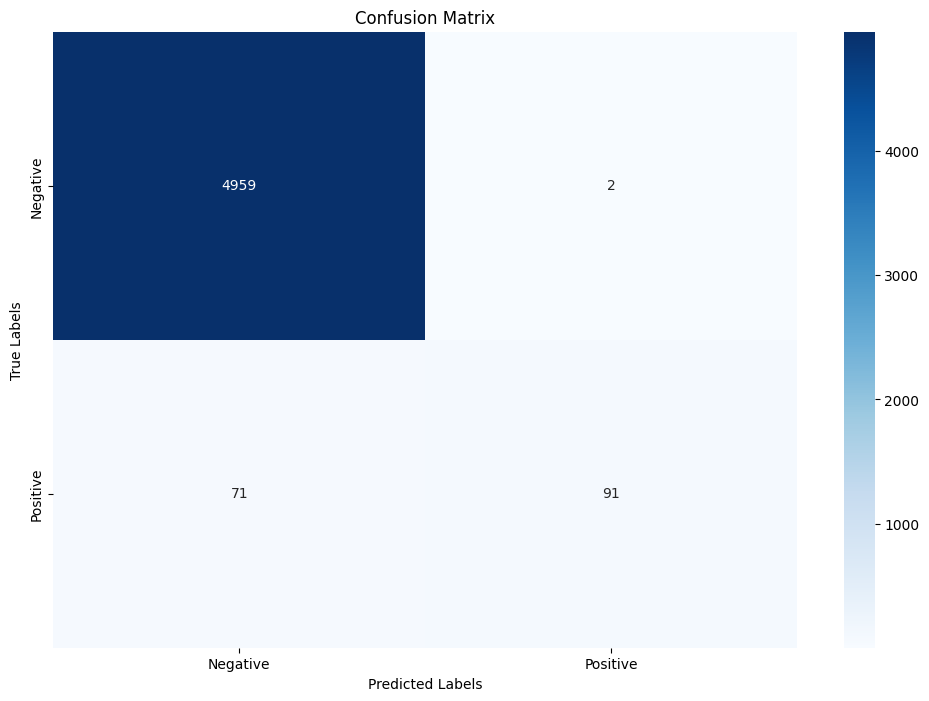

In [47]:
plt.figure(figsize=(12,8))

conf_matrix = confusion_matrix(y_test, y_test_pred)

sns.heatmap(conf_matrix, cmap='Blues', annot=True, fmt='g')

plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

labels = ['Negative', 'Positive']
plt.xticks(np.arange(len(labels))+0.5, labels)
plt.yticks(np.arange(len(labels))+0.5, labels)

plt.show()


# tests

In [48]:
proba , df_naive = pre.Naive_Bayes(df , target_name='fraudulent')

In [49]:
len(proba)

2

In [50]:
df_naive

,salary_range,telecommuting,has_company_logo,has_questions,fraudulent,location_probs,company_profile_probs,description_probs,benefits_probs,employment_type_probs,job_field_probs,Requirements_probs
0,0,0,1,0,0,-1.885434,-16.940644,-17.999672,-0.207386,0.244166,-3.713935,-4.260521
1,0,0,1,0,0,0.000000,-2.053151,-36.091576,11.024746,-0.048540,-1.591597,-25.362766
2,0,0,1,0,0,0.376426,0.823978,1.175158,-0.207386,0.244166,2.704396,28.243313
3,0,0,1,0,0,-2.068709,-0.658156,-39.381862,-8.342897,-0.048540,-3.135024,-12.056469
4,0,0,1,1,0,2.814330,-5.090116,28.629014,0.540230,-0.048540,0.593642,-2.190708
...,...,...,...,...,...,...,...,...,...,...,...,...
17070,0,0,0,0,0,0.092039,3.230982,-23.283652,-0.207386,-0.339852,-5.057049,-17.991131
17071,0,0,1,1,0,1.625891,4.590529,-22.167647,-6.043945,-0.048540,3.580498,-7.736215
17072,0,0,0,0,0,0.092039,3.230982,1.777478,-0.207386,-0.339852,-5.674305,4.203077
17073,0,0,1,1,0,0.235803,4.590529,-25.091031,-6.043945,-0.048540,1.976652,-5.742704


In [51]:
x = df_naive.drop(['fraudulent'] , axis = 1)
y = df_naive['fraudulent']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3 , random_state = 42)

In [52]:
model = RandomForestClassifier(n_estimators=200 , n_jobs=-1)
model.fit(x_train , y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1)

In [53]:
from sklearn.metrics import classification_report
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

train_report = classification_report(y_train , y_train_pred)
test_report = classification_report(y_test , y_test_pred)

print('Train Report', '\n', train_report)
print('Test Report', '\n', test_report)



Train Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     11576
           1       1.00      1.00      1.00       376

    accuracy                           1.00     11952
   macro avg       1.00      1.00      1.00     11952
weighted avg       1.00      1.00      1.00     11952

Test Report 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      4961
           1       0.96      0.80      0.87       162

    accuracy                           0.99      5123
   macro avg       0.98      0.90      0.93      5123
weighted avg       0.99      0.99      0.99      5123



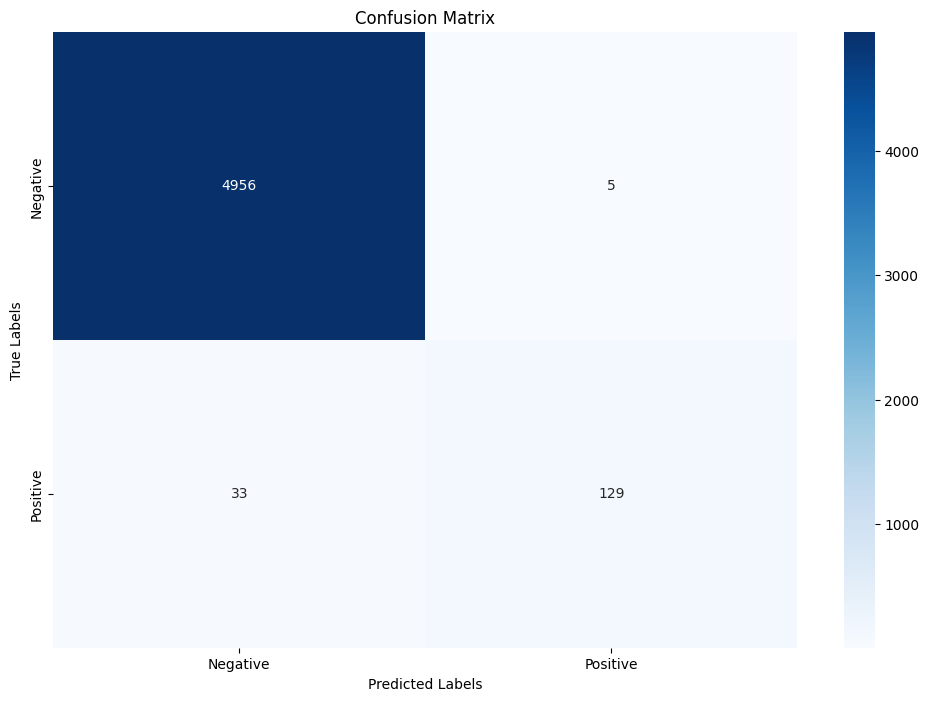

In [54]:
plt.figure(figsize=(12,8))

conf_matrix = confusion_matrix(y_test, y_test_pred)

sns.heatmap(conf_matrix, cmap='Blues', annot=True, fmt='g')

plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

labels = ['Negative', 'Positive']
plt.xticks(np.arange(len(labels))+0.5, labels)
plt.yticks(np.arange(len(labels))+0.5, labels)

plt.show()


In [55]:
!pip install streamlit -q
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 48.2 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇npm notice
npm notice New major version of npm available! 10.8.2 -> 11.13.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.13.0
npm notice To update run: npm install -g npm@11.13.0
npm notice
⠇

In [56]:
%%writefile app.py
import streamlit as st

st.title("🔍 Fake Job Detector")
st.write("This is running live from Colab!")
# Add your model loading and prediction logic here

Writing app.py


In [57]:
import urllib
print("Password/Enpoint IP for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

Password/Enpoint IP for localtunnel is: 34.50.174.174


In [59]:
# Install Cloudflared
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

# Run Streamlit and Cloudflared together
import os
os.system("streamlit run app.py & cloudflared tunnel --url http://localhost:8501 &")

--2026-05-06 12:19:16--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb [following]
--2026-05-06 12:19:17--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/ec689fe1-d727-4ebd-bbc3-5967730ab54e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-06T12%3A53%3A43Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64.deb&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&

0

In [60]:
import joblib
# Assuming 'model' is your trained RandomForestClassifier from cell [45]
joblib.dump(model, 'model.pkl')

['model.pkl']

In [61]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd

st.title("🔍 Fake Job Detection Dashboard")

# Load the model
try:
    model = joblib.load('model.pkl')
    st.success("Model loaded successfully!")
except:
    st.error("Model file not found. Please run the training cell in Colab first.")

# Add UI elements
job_description = st.text_area("Paste Job Description here:")
if st.button("Check for Fraud"):
    st.write("Analyzing...")
    # Add your prediction logic here

Overwriting app.py


In [62]:
import os
import threading

# Function to run the tunnel
def run_tunnel():
    os.system("cloudflared tunnel --url http://localhost:8501")

# Start Streamlit in the background
os.system("streamlit run app.py &")

# Start Cloudflare tunnel in a separate thread
threading.Thread(target=run_tunnel).start()

In [63]:
!grep -o 'https://[-0-9a-z]*\.trycloudflare.com' nohup.out || echo "Waiting for link..."
!streamlit run app.py & cloudflared tunnel --url http://localhost:8501 > tunnel.log 2>&1 &
import time
time.sleep(5)
!grep -o 'https://[-0-9a-z]*\.trycloudflare.com' tunnel.log

grep: nohup.out: No such file or directory
Waiting for link...


2026-05-06 12:23:55.266 Uvicorn server started on 0.0.0.0:8503

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8503
  Network URL: http://172.28.0.12:8503
  External URL: http://34.50.174.174:8503

  Stopping...
https://law-lung-log-adoption.trycloudflare.com
